In [1]:
## Imports

import sys, os
from pathlib import Path

parent_folder = str(Path.cwd().parents[0])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)

from sigpy import mri
from sklearn.decomposition import PCA
import pickle
import sigpy as sp
import cupy as cp
import numpy as np
import pickle
import twixtools
import matplotlib.pyplot as plt
from sigpy.mri.app import TotalVariationRecon
from scipy.signal import butter,filtfilt
from gating_functions import phase_based_gating_updated
from admm.utils_moco import stacked_nufft_operator,golden_angle_2d_readout, golden_angle_coords_3d, pocs, phase_based_gating_peak_to_peak, phase_based_gating, create_gates

In [2]:

data_path = Path('/home/lilianae/data/NaF_MtSinai/')
output_path = parent_folder/Path('data/processed/')
print(f'output path = {output_path}')

if not os.path.exists(output_path):
    os.makedirs(output_path)

# data_file = data_path /'anon_meas_MID00118_FID60738_Tho_fl3d_star_vibe_991_nav_tj_2000sp_AllCoils_SOS.dat'
data_file_pt2 = '/home/lilianae/data/NaF_Patient2/anon_meas_MID00063_FID64627_fl3d_star_vibe_991_nav_tj_2000sp_AllCoils_SOS_1.dat'

multi_twix = twixtools.read_twix(str(data_file_pt2))
mapped = twixtools.map_twix(multi_twix)


# mapped[0] is sens data

data_0 = mapped[0]['image']
print(data_0.non_singleton_dims)
data_0.flags['remove_os']=True

echo_num=0                                                  # first echo is spoke data
num_points = int(mapped[0]['hdr']['Config']['NImageLins'])  # number of points on one spoke
kspace_0 = data_0[...,echo_num,0,0,0,:,0,0,:,:,:num_points]
kspace_0 = kspace_0.squeeze()
kspace_0 = np.transpose(kspace_0,(2,0,1,3))
print(kspace_0.shape)  ## Shape = (15, 58, 2002, 256) -> (channels, partitions, lines, columns)
## 58 excitations of the same spoke -> one dimension will be 100,000 (temporal dimension)


output path = /home/lilianae/projects/data/processed
Software version: VD/VE (!?)

Scan  0


100%|██████████| 15.9G/15.9G [00:12<00:00, 1.37GB/s]


['Eco', 'Par', 'Lin', 'Cha', 'Col']
(15, 58, 2002, 256)


TR from data: 0.006 sec
Sampling frequency (Hz): 166.667
full timescale goes to 696.69
coil matrix shape: (15, 116116)


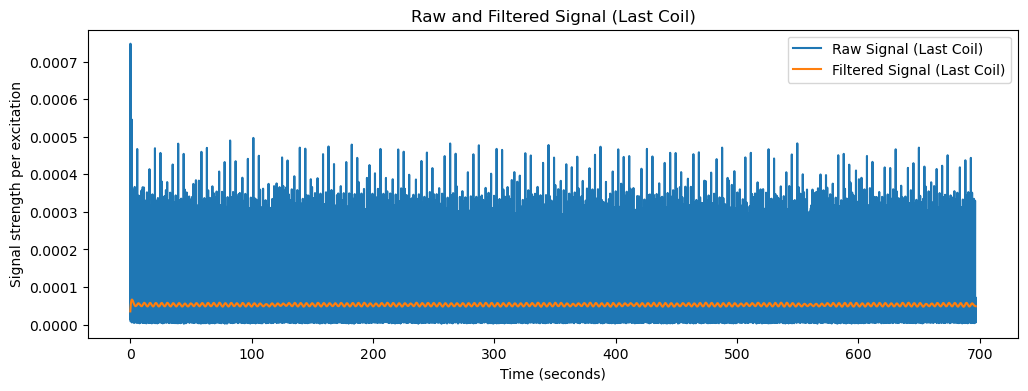

Explained variance ratio: [0.59591176]


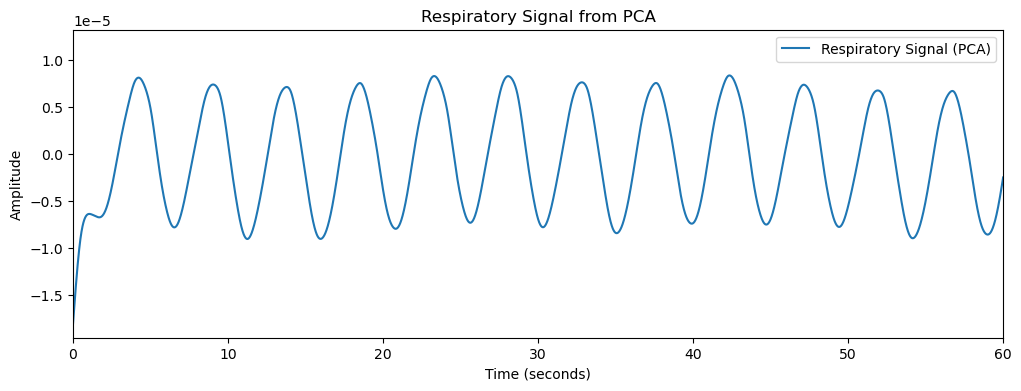

In [3]:
def butter_lowpass_filter(data, cutoff_hz, fs_hz, order=2):
    nyq = 0.5 * fs_hz
    normal_cutoff = cutoff_hz / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

def get_resp_signal(ksp_data, mapped):
    num_coils, num_slices, num_spokes, num_samples = ksp_data.shape

    TR = float(mapped[0]['hdr']['Config']['TR'])/1000000. ## microseconds to seconds
    print(f"TR from data: {TR} sec")

    n_samples = num_spokes * num_slices  # total time points/temporal samples

    # Sampling frequency in Hz
    fs = 1/(TR)
    print(f"Sampling frequency (Hz): {fs:.3f}")

    cutoff = 0.25  # respiratory frequency in Hz (~15 bpm)

    # Sanity check: cutoff must be less than Nyquist
    if cutoff >= fs / 2:
        cutoff = 0.49 * fs
        print(f"Cutoff frequency adjusted to: {cutoff:.3f} Hz to stay below Nyquist")

    # Build full time scale in SECONDS
    full_time_scale_s = np.arange(n_samples) * TR  # time in s
    print(f'full timescale goes to {full_time_scale_s[-1]}')

    signal_all_coils = []
    for c in range(num_coils):
        # mean magnitude over samples 130:140, shape (num_slices, num_spokes)
        signal = np.mean(np.abs(ksp_data[c, :, :, 130:140]), axis=-1)
        signal = signal.T.flatten()  # flatten to 1D (time points)

        filtered_signal = butter_lowpass_filter(signal, cutoff, fs, order=2)
        signal_all_coils.append(filtered_signal)

    coil_matrix = np.stack(signal_all_coils, axis=0)  # shape: (coils, time points)

    print(f"coil matrix shape: {coil_matrix.shape}")

    # plot raw and filtered signal from last coil as example (time in seconds)
    plt.figure(figsize=(12, 4))
    plt.plot(full_time_scale_s, signal, label="Raw Signal (Last Coil)")
    plt.plot(full_time_scale_s, filtered_signal, label="Filtered Signal (Last Coil)")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Signal strength per excitation")
    plt.title("Raw and Filtered Signal (Last Coil)")
    plt.legend()
    # plt.xlim(0, 60)  # show first 60 seconds
    plt.show()

    return coil_matrix, TR

def perform_pca(coil_matrix, n_components=1):
    # coil_matrix shape: (coils, time_points)
    data_for_pca = coil_matrix.T  # shape: (time_points, coils)
    pca = PCA(n_components=n_components)
    pcs = pca.fit_transform(data_for_pca)

    print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
    return pcs, pca.explained_variance_ratio_

def plot_resp_signal(pcs, TR):
    n_samples = pcs.shape[0]
    time_ms = np.arange(n_samples) * TR
    plt.figure(figsize=(12, 4))
    plt.plot(time_ms, pcs[:, 0], label="Respiratory Signal (PCA)")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.title("Respiratory Signal from PCA")
    plt.legend()
    plt.xlim(0, 60)
    plt.show()

coil_matrix, TR = get_resp_signal(kspace_0, mapped)
pcs, _ = perform_pca(coil_matrix, n_components=1)
plot_resp_signal(pcs, TR)
resp_signal = pcs[:,0]

Gate 0: kspace shape = (15, 58, 496, 256), coords shape = (58, 496, 256, 3)
Gate 1: kspace shape = (15, 58, 996, 256), coords shape = (58, 996, 256, 3)
Gate 2: kspace shape = (15, 58, 496, 256), coords shape = (58, 496, 256, 3)


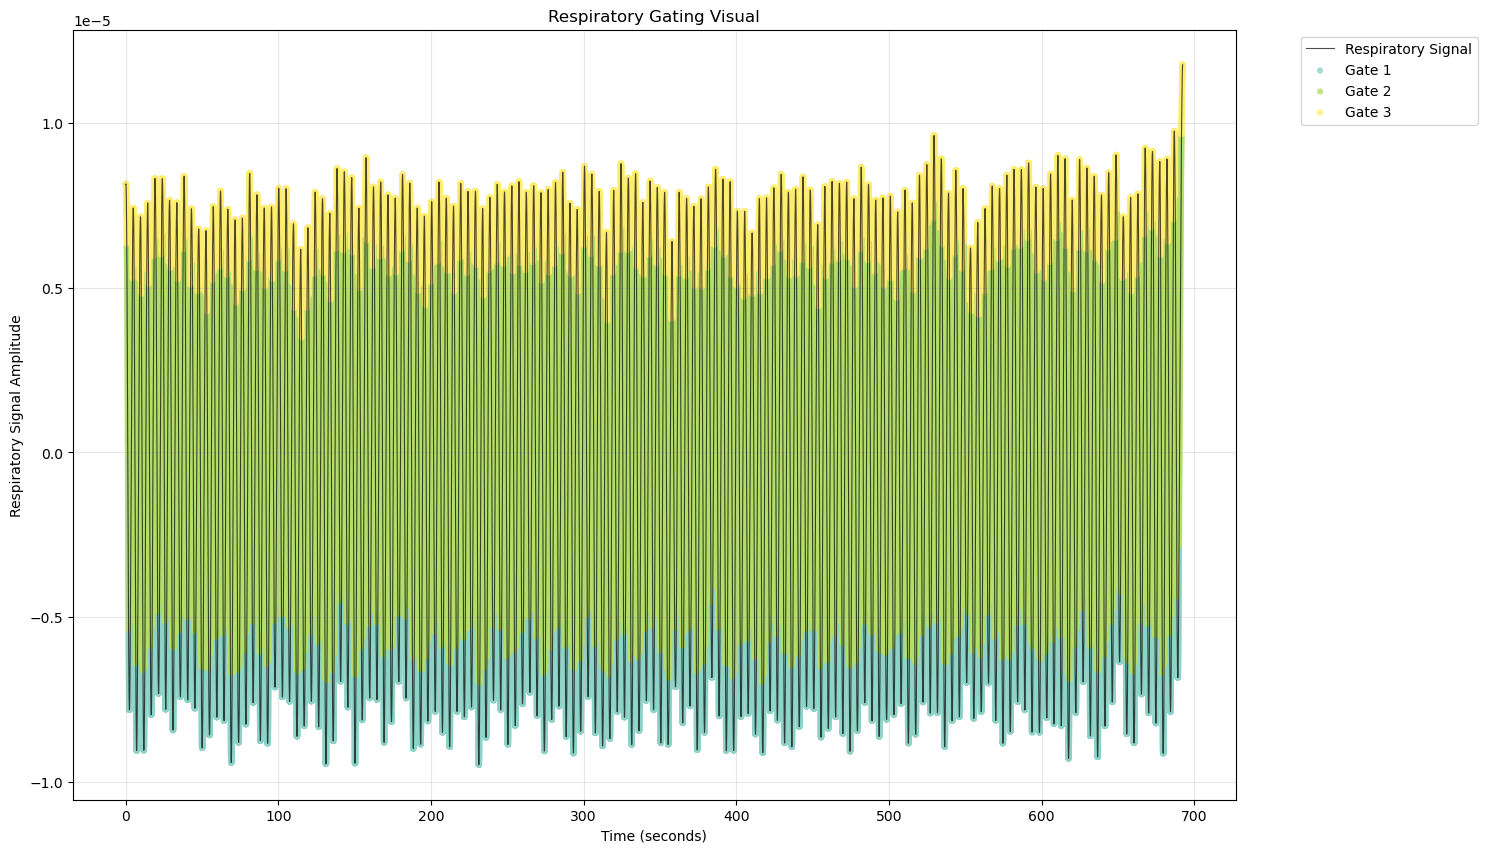

In [4]:
def create_gates_updated(ksp,coords, idx,num_gates):
    data_bins=[]
    spoke_bins=[]

    for bin in range(1,num_gates+1):
        current_kspace = ksp[:,(idx==bin),:]
        data_bins.append(current_kspace)
        current_ks = coords[(idx==bin),...]
        spoke_bins.append(current_ks)

    return data_bins, spoke_bins

def reshape_gate(data_bin, spoke_bin, num_coils, num_slices, num_samples, ndims):
    N = data_bin.shape[1]
    max_valid = (N // num_slices) * num_slices
    
    data_bin = data_bin[:, :max_valid, :]
    spoke_bin = spoke_bin[:max_valid, :, :]

    num_spokes_per_slice = max_valid // num_slices
    data_bin = data_bin.reshape(num_coils, num_slices, num_spokes_per_slice, num_samples)
    spoke_bin = spoke_bin.reshape(num_slices, num_spokes_per_slice, num_samples, ndims)

    return data_bin, spoke_bin

def gate_resp_signal(ksp_data, resp_signal, num_gates, img_shape, spokes_to_discard=700):
    # Do not use the transient part of the signal (the large overshoot) for gating
    resp_trimmed = resp_signal[spokes_to_discard:]
    
    num_coils, num_slices, num_spokes, num_samples = kspace_0.shape
    idx = phase_based_gating_updated(resp_trimmed, num_gates, order=25)

    ## divide kspace and spoke data:
    img_shape = (58,256,256) 
    coords = golden_angle_coords_3d(img_shape,num_spokes,num_samples)
    ndims = coords.shape[-1]

    ### Combine slice and spoke dimension so we have all temporal samples
    kspace_temporal = np.reshape(kspace_0, (num_coils, num_slices*num_spokes, num_samples))
    kspace_trimmed = kspace_temporal[:, spokes_to_discard:, :]
    coords_temporal = np.reshape(coords, (num_slices*num_spokes, num_samples, ndims))
    coords_trimmed = coords_temporal[spokes_to_discard:, :, :]

    ### Check shape
    # print(f'kspace_trimmed.shape = {kspace_trimmed.shape}')
    # print(f'coords_trimmed.shape = {coords_trimmed.shape}')

    data_bins, spoke_bins = create_gates_updated(kspace_trimmed, coords_trimmed, idx, num_gates)
    for i in range(num_gates):
        data_bins[i], spoke_bins[i] = reshape_gate(data_bins[i], spoke_bins[i], num_coils, num_slices, num_samples, ndims)
        print(f"Gate {i}: kspace shape = {data_bins[i].shape}, coords shape = {spoke_bins[i].shape}")

    return idx, resp_trimmed, data_bins, spoke_bins


def visualize_resp_gating(resp_signal, idx, TR, num_gates, title="Respiratory Gating Visual"):
    ## 1. Create time axis
    time_s = np.arange(len(resp_signal))*TR

    fig = plt.figure(figsize=(15, 10))

    ## Define colors for gates
    gate_colors = plt.cm.Set3(np.linspace(0,1, num_gates))

    ## Plot 1: Signal with color coded gates
    plt.plot(time_s, resp_signal, 'k-', linewidth=0.8, alpha=0.7, label="Respiratory Signal")

    for i in range(1,(num_gates+1)):
        mask = (idx==i)
        if np.any(mask):
            plt.scatter(time_s[mask], resp_signal[mask],
                        c=[gate_colors[i-1]], s=20, alpha=0.8, label=f'Gate {i}', edgecolors='none')
    
    plt.xlabel('Time (seconds)')
    plt.ylabel('Respiratory Signal Amplitude')
    plt.title(f'{title}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()

ncoils, nslices, nspokes, nsamples = kspace_0.shape
num_gates = 3
img_shape = (nslices, nsamples, nsamples)
idx, resp_trimmed, data_bins, spoke_bins = gate_resp_signal(kspace_0, resp_signal, num_gates=num_gates, img_shape=img_shape)
visualize_resp_gating(resp_trimmed, idx, TR, num_gates=num_gates)

### Inspect Spoke Distribution Across Gates

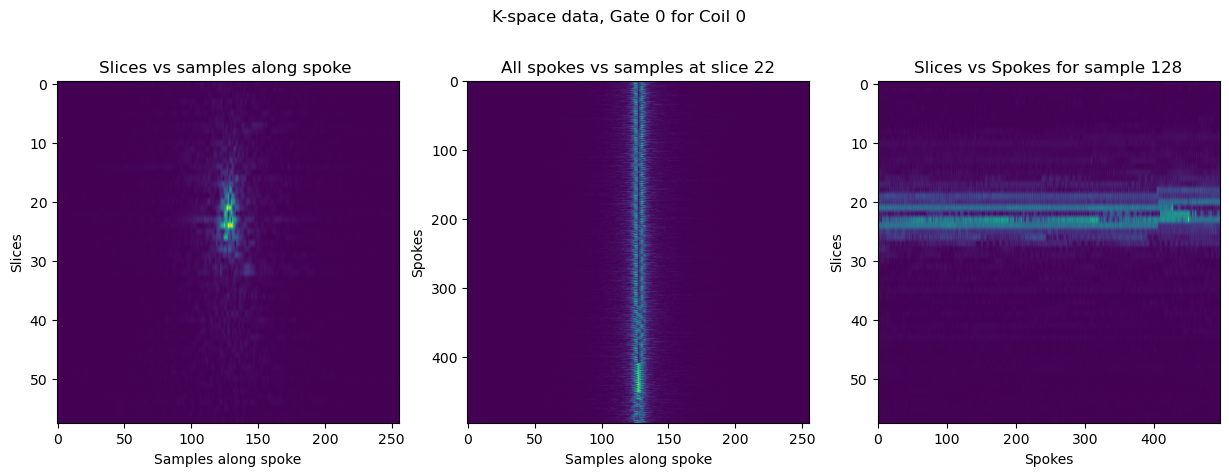

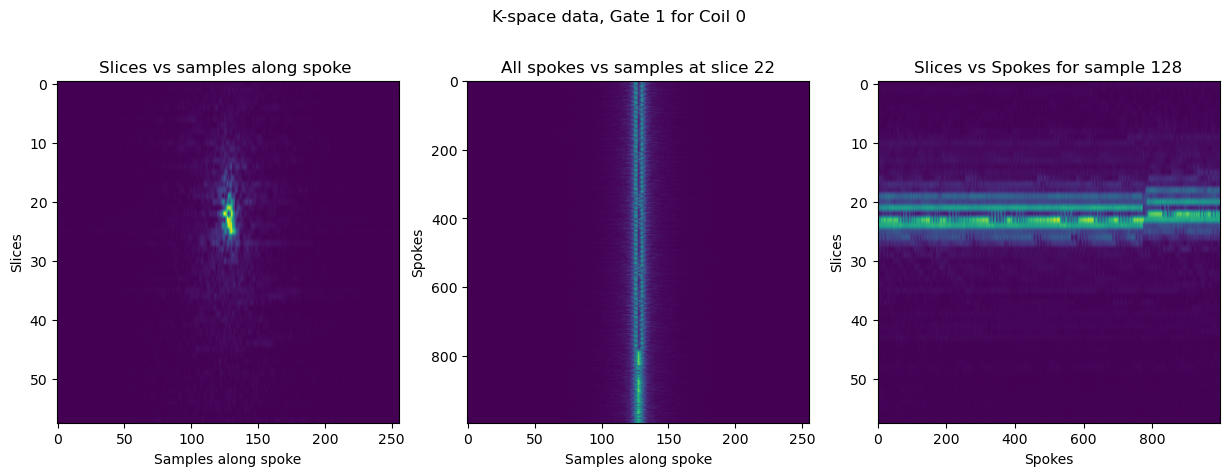

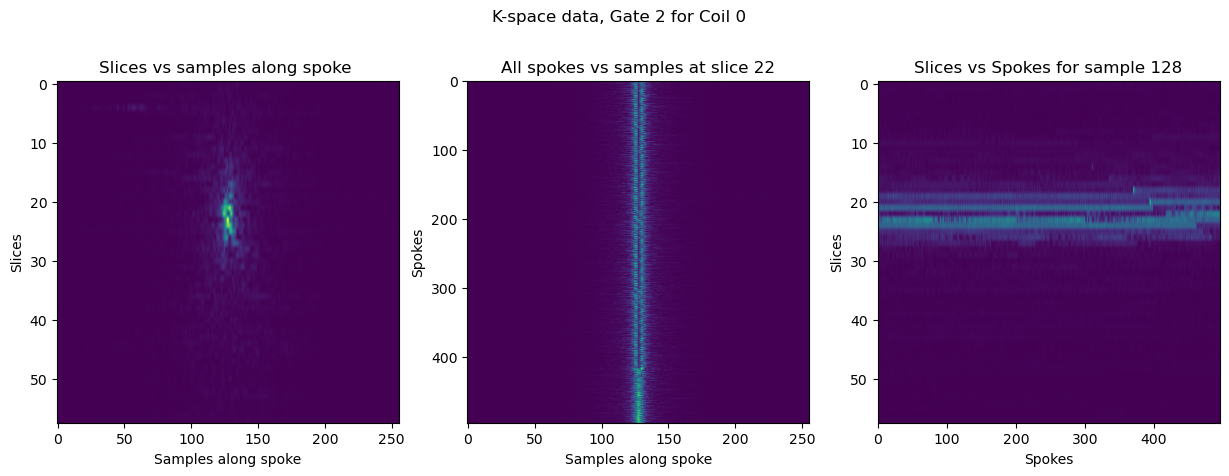

In [5]:
# show slice x line; check, where the kspace center in the through-slice 
# direction is (may not be in the exact middle due to partial Fourier etc.)

def plot_ksp_data(ksp_data, coil_idx, center_slice = None, center_sample = None, title_info="", data_bin=None):

    ## Get all dims 
    ncoils, nslices, nspokes, nsamples= ksp_data.shape

    ## If center idx not given, assume it is middle
    if center_slice is None:
        center_slice = nslices // 2
    
    if center_sample is None:
        center_sample = nsamples //2

    fig, axs = plt.subplots(1, 3, figsize=(15,5))

    ## Plot spokes vs slices
    axs[0].imshow(np.abs(ksp_data[0, :, 0, :]), aspect=nsamples/nslices)

    axs[0].set_xlabel("Samples along spoke")
    axs[0].set_ylabel("Slices")
    axs[0].set_title(f"Slices vs samples along spoke {title_info}")

    ## Plot spokes vs samples for center idx 
    axs[1].imshow(np.abs(ksp_data[0, center_slice, :, :]), aspect=nsamples/nspokes)
    axs[1].set_xlabel("Samples along spoke")
    axs[1].set_ylabel("Spokes")
    axs[1].set_title(f"All spokes vs samples at slice {center_slice}")

    ## Plot all slices vs center sample
    axs[2].imshow(np.abs(ksp_data[0, :, :, center_sample]), aspect=nspokes/nslices)
    axs[2].set_xlabel("Spokes")
    axs[2].set_ylabel("Slices")
    axs[2].set_title(f"Slices vs Spokes for sample {center_sample}")
    
    fig.suptitle(f"K-space data, Gate {data_bin} for Coil {coil_idx}")

    plt.show()

plot_ksp_data(data_bins[0], coil_idx=0, center_slice=22, data_bin=0)
plot_ksp_data(data_bins[1], coil_idx=0, center_slice=22, data_bin=1)
plot_ksp_data(data_bins[2], coil_idx=0, center_slice=22, data_bin=2)

Analyze spoke angles

Analyzing spoke distribution for gate 0, all 58 slices
SLICE = 0
  Number of spokes in gate 0: 496
  kx shape = (126976,), ky shape = (126976,)
  Angle range: 0.0° to 359.9°
  Angle spread: 359.9°
  Mean angle: 180.1°
  Stored data for slice 0
----------------------------------------
SLICE = 1
  Number of spokes in gate 0: 496
  kx shape = (126976,), ky shape = (126976,)
  Angle range: 0.0° to 359.9°
  Angle spread: 359.9°
  Mean angle: 179.6°
  Stored data for slice 1
----------------------------------------
SLICE = 2
  Number of spokes in gate 0: 496
  kx shape = (126976,), ky shape = (126976,)
  Angle range: 0.0° to 359.9°
  Angle spread: 359.9°
  Mean angle: 179.7°
  Stored data for slice 2
----------------------------------------
SLICE = 3
  Number of spokes in gate 0: 496
  kx shape = (126976,), ky shape = (126976,)
  Angle range: 0.0° to 359.9°
  Angle spread: 359.9°
  Mean angle: 179.9°
  Stored data for slice 3
----------------------------------------
SLICE = 4
  Number of spo

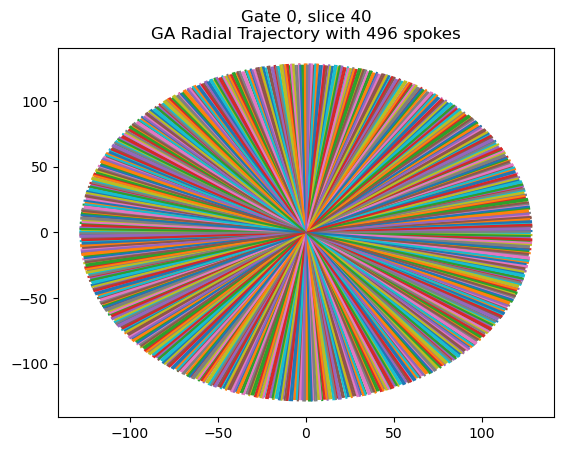

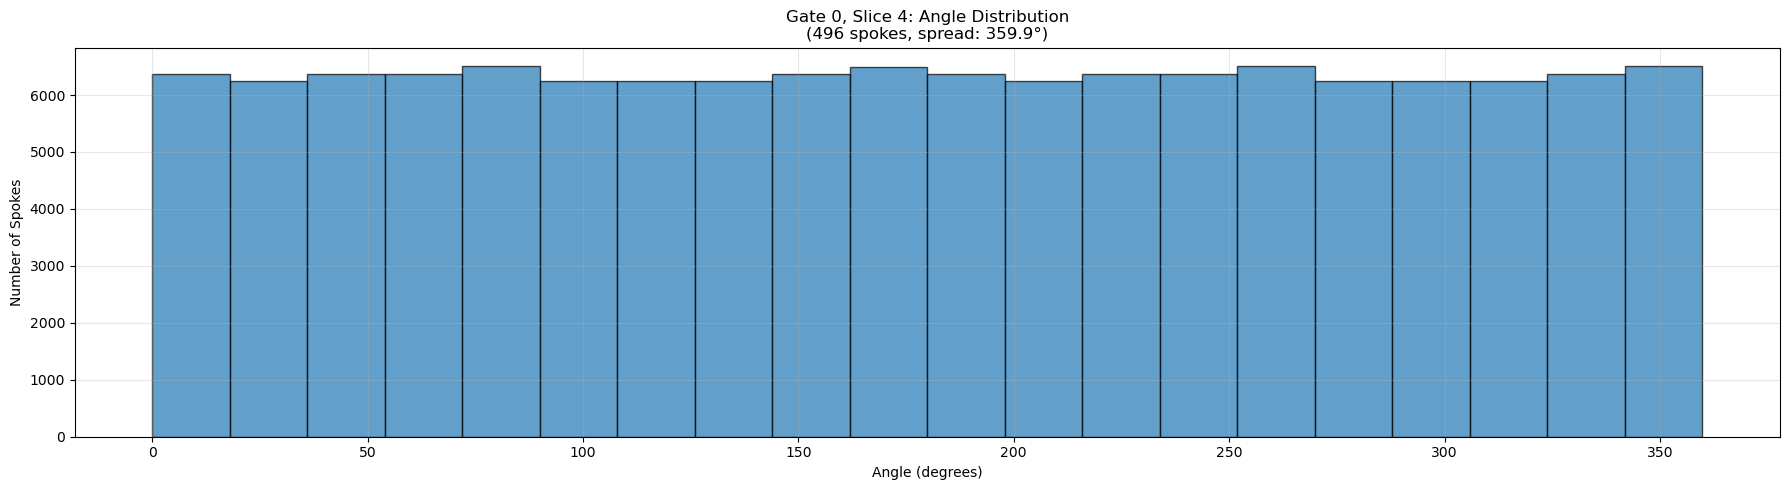

In [6]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import seaborn as sns

def analyze_spoke_angles(spoke_bins, data_bins, gate, slice_idx=None):
    '''Analyze angular distribution of spokes within each gate
   
    Params
    ----------------------
    spoke_bins: list of ndarrays
        GA coordinates for each gate, each with shape = (nslices, nspokes, nsamples, ndims)
   
    data_bins: list of ndarrays
        Gated k-space data for each gate, each with shape = (ncoils, nslices, nspokes, nsamples)
   
    gate: int
        Gate index to analyze
   
    slice_idx: int or list
        Slice(s) to analyze. If None, analyze all slices
   
    Returns
    -------
    all_slice_data: dict
        Dictionary containing angle analysis for each slice
    '''
    
    # Get shapes
    ncoils, nslices, _, nsamples = data_bins[gate].shape
    
    # Handle slice selection
    if slice_idx is None:
        slices_for_analysis = range(nslices)
        analysis_title = f'all {nslices} slices'
    elif isinstance(slice_idx, (list, tuple)):
        slices_for_analysis = slice_idx
        analysis_title = f'slices {slice_idx}'
    else:
        slices_for_analysis = [slice_idx]
        analysis_title = f'slice {slice_idx}'
    
    print(f'Analyzing spoke distribution for gate {gate}, {analysis_title}')
    print("="*60)
    
    ## Storage for all slice data
    all_slice_data = {}
    
    for s in slices_for_analysis:
        print(f'SLICE = {s}')
        
        ## Get coordinates for this slice and gate
        coords = spoke_bins[gate][s, :, :, :]  # Shape: (nspokes, nsamples, ndims)
        nspokes_gate = coords.shape[0]
        
        ## Calculate angle from center of k-space using coords
        center_idx = nsamples // 2
        
        kx = coords[:, :, 2].flatten()  # x coord at center sample
        ky = coords[:, :, 1].flatten()  # y coord at center sample
        
        print(f'  Number of spokes in gate {gate}: {nspokes_gate}')
        print(f'  kx shape = {kx.shape}, ky shape = {ky.shape}')
        
        ## Calculate polar angles
        angles = np.arctan2(ky, kx) * (180/np.pi)
        angles = (angles + 360) % 360  # Convert to 0-360 range
        
        print(f'  Angle range: {np.min(angles):.1f}° to {np.max(angles):.1f}°')
        print(f'  Angle spread: {np.ptp(angles):.1f}°')
        print(f'  Mean angle: {np.mean(angles):.1f}°')
        
        ## Store slice information
        all_slice_data[s] = {
            'slice': s,
            'gate': gate,
            'num_spokes': nspokes_gate,
            'angles': angles,
            'angle_range': np.ptp(angles),
            'angle_std': np.std(angles),
            'min_angle': np.min(angles),
            'max_angle': np.max(angles),
            'mean_angle': np.mean(angles),
            'kx': kx,
            'ky': ky
        }
        
        print(f'  Stored data for slice {s}')
        print("-" * 40)
    
    return all_slice_data


def plot_single_slice_angles(slice_data, slice_idx, gate):
    '''Plot angular analysis for a single slice'''
    
    if slice_idx not in slice_data:
        print(f"No data found for slice {slice_idx}")
        return
    
    data = slice_data[slice_idx]
    angles = data['angles']
    kx = data['kx']
    ky = data['ky']
    
    fig, axes = plt.subplots(1, 1, figsize=(18, 5))
    
    # Plot 1: Histogram of angles
    axes.hist(angles, bins=20, alpha=0.7, edgecolor='black')
    axes.set_xlabel('Angle (degrees)')
    axes.set_ylabel('Number of Spokes')
    axes.set_title(f'Gate {gate}, Slice {slice_idx}: Angle Distribution\n'
                     f'({data["num_spokes"]} spokes, spread: {data["angle_range"]:.1f}°)')
    axes.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_GA_trajectory(slice_data, slice_idx, gate_idx):
    num_spokes = slice_data[slice_idx]['num_spokes']
    kx_flat = slice_data[slice_idx]['kx']
    ky_flat = slice_data[slice_idx]['ky']

    kx = np.reshape(kx_flat, (num_spokes, -1))
    ky = np.reshape(ky_flat, (num_spokes, -1))
    for i in range(num_spokes):
        plt.plot(kx[i, :], ky[i, :])
    plt.title(f"Gate {gate_idx}, slice {slice_idx}\nGA Radial Trajectory with {num_spokes} spokes")
    plt.show()

gate0_slice_data = analyze_spoke_angles(spoke_bins, data_bins, gate=0, slice_idx=None)
plot_GA_trajectory(gate0_slice_data, slice_idx=40, gate_idx=0)
plot_single_slice_angles(gate0_slice_data, slice_idx=4, gate=0)
# gate2_slice_data = analyze_spoke_angles(spoke_bins, data_bins, gate=2, slice_idx=[1,2,3,4,5])

# gate0_slice_data = analyze_spoke_angles(spoke_bins, data_bins, gate=2, slice_idx=None)
# plot_GA_trajectory(gate0_slice_data, slice_idx=40, gate_idx=2)
# plot_single_slice_angles(gate0_slice_data, slice_idx=4, gate=2)



### Load L1 Wavelet Data (Execution in different script)

In [7]:
## Load pickle file from TotalVariation reconstruction

data_l1_sweep = '/home/lilianae/projects/naf_recons/l1_sweep_results/og_gating/Patient2'

l1_gate_files = [
    'l1_sweep_gate0_lambda2.pkl',
    'l1_sweep_gate1_lambda2.pkl',
    'l1_sweep_gate2_lambda2.pkl'
]

l1_results_list = []
for fname in l1_gate_files:
    with open(os.path.join(data_l1_sweep, fname), 'rb') as f:
        l1_results_list.append(pickle.load(f))

for i, l1_results in enumerate(l1_results_list):
    print(f'Gate {i}:')
    print(f'  l1_results.keys() = {l1_results.keys()}')
    print(f'  # of reconstructions = {len(l1_results["reconstructions"])}')
    print(f'  l1_results["reconstructions"].keys() = {l1_results["reconstructions"].keys()}')
    print(f'  l1_results["reconstructions"][1e-05].shape = {l1_results["reconstructions"][1e-05].shape}')

Gate 0:
  l1_results.keys() = dict_keys(['lambda_values', 'img_shape', 'max_iter', 'reconstructions', 'timing', 'parameters'])
  # of reconstructions = 2
  l1_results["reconstructions"].keys() = dict_keys([1e-05, 0.0001])
  l1_results["reconstructions"][1e-05].shape = (58, 256, 256)
Gate 1:
  l1_results.keys() = dict_keys(['lambda_values', 'img_shape', 'max_iter', 'reconstructions', 'timing', 'parameters'])
  # of reconstructions = 2
  l1_results["reconstructions"].keys() = dict_keys([1e-05, 0.0001])
  l1_results["reconstructions"][1e-05].shape = (58, 256, 256)
Gate 2:
  l1_results.keys() = dict_keys(['lambda_values', 'img_shape', 'max_iter', 'reconstructions', 'timing', 'parameters'])
  # of reconstructions = 2
  l1_results["reconstructions"].keys() = dict_keys([1e-05, 0.0001])
  l1_results["reconstructions"][1e-05].shape = (58, 256, 256)


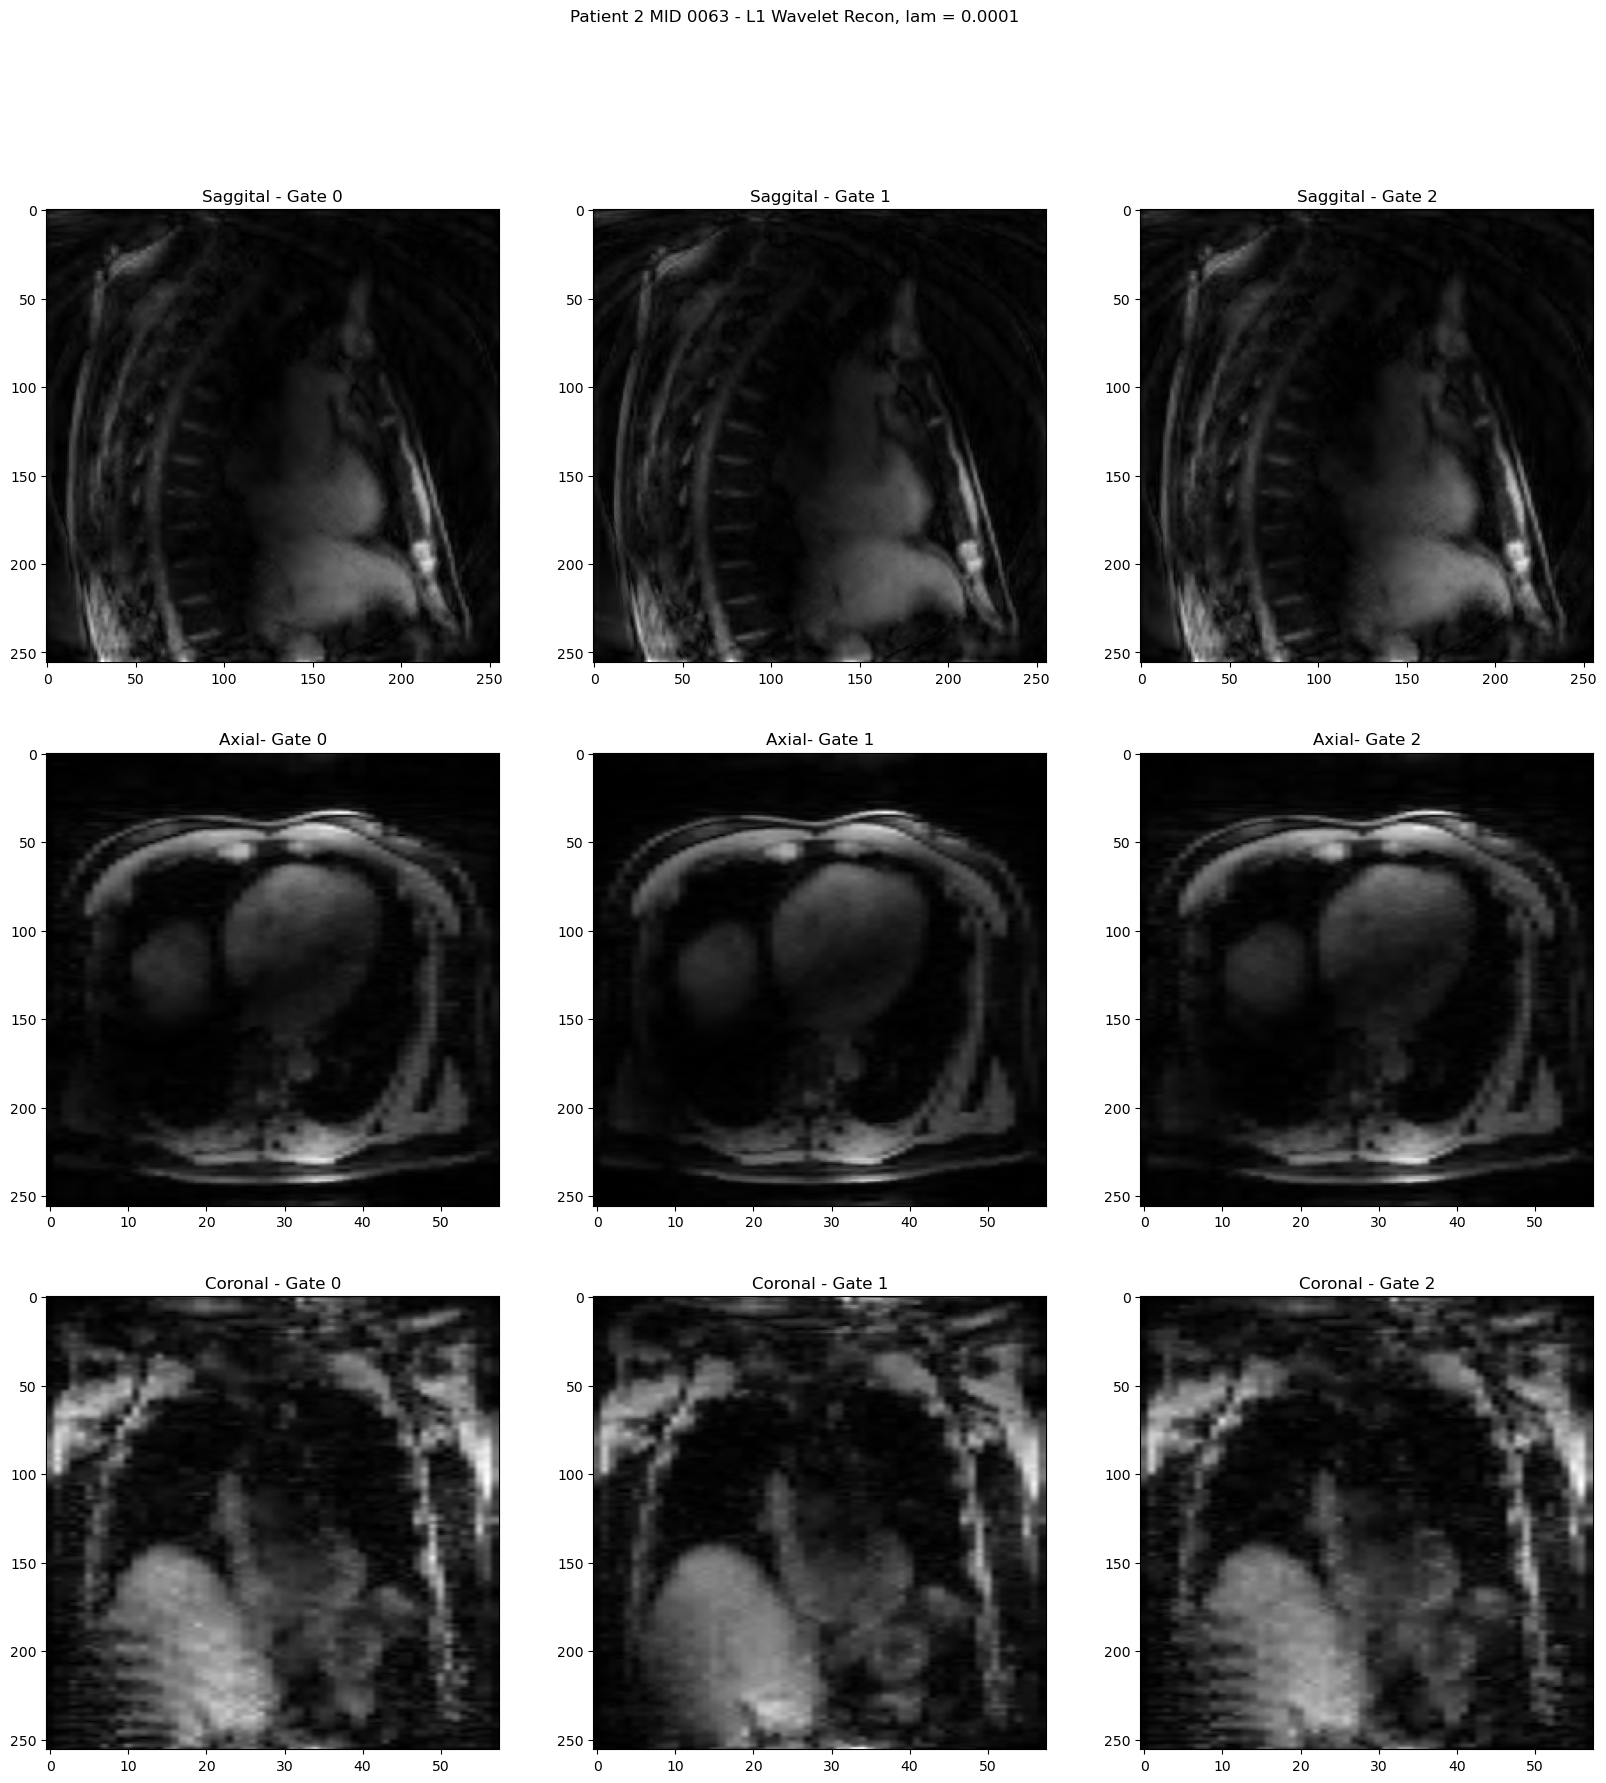

In [15]:
lambda_values = l1_results["reconstructions"].keys()
from scipy import ndimage
def rotate_90(img):
    return ndimage.rotate(img,-90)

fig, axs = plt.subplots(3, 3, figsize=(20,20))

for i, gate in enumerate([0,1,2]):
    l1_results = l1_results_list[gate]
    
    lam = 0.0001
    
    output1 = np.abs(l1_results["reconstructions"][lam])

    Nz, Ny, Nx = output1.shape 

    axs[0, i].imshow(output1[30, :, :], cmap='gray')
    axs[0, i].set_title(f"Saggital - Gate {gate}")
    axs[1, i].imshow(np.flipud(rotate_90(output1[:, 150, :])), aspect=Nz/Ny, cmap='gray')
    axs[1, i].set_title(f"Axial- Gate {gate}")
    axs[2, i].imshow(rotate_90(output1[:, :, 130]), aspect=Nz/Ny, cmap='gray')
    axs[2, i].set_title(f"Coronal - Gate {gate}")
    fig.suptitle(f"Patient 2 MID 0063 - L1 Wavelet Recon, lam = {0.0001}")
plt.show()

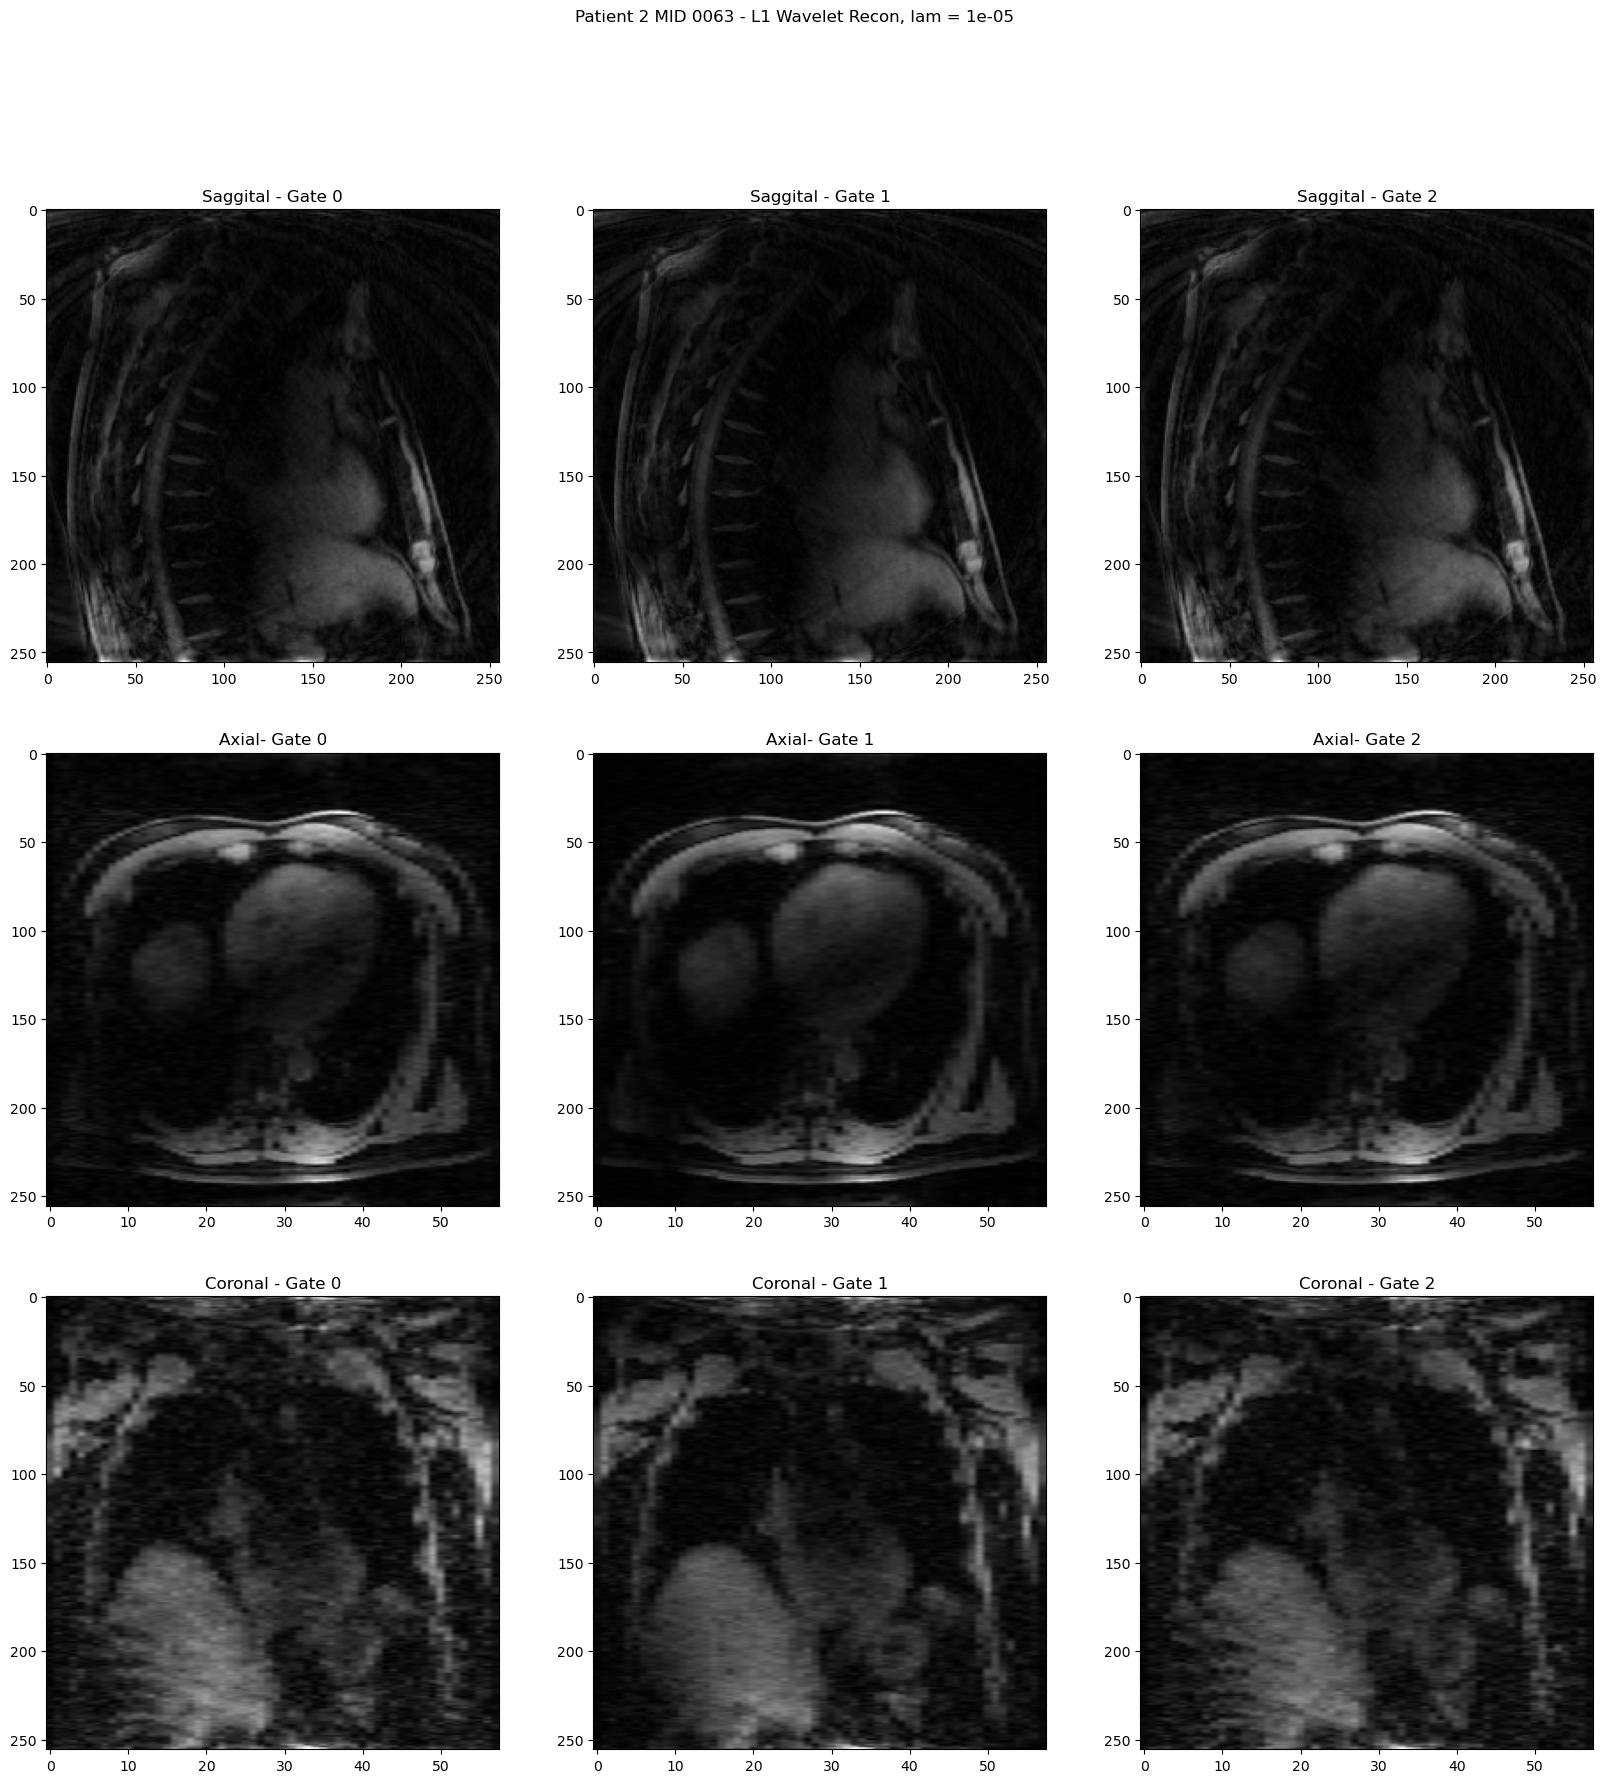

In [14]:
lambda_values = l1_results["reconstructions"].keys()
from scipy import ndimage
def rotate_90(img):
    return ndimage.rotate(img,-90)

fig, axs = plt.subplots(3, 3, figsize=(20,20))

for i, gate in enumerate([0,1,2]):
    l1_results = l1_results_list[gate]
    
    lam = 1e-5
    
    output1 = np.abs(l1_results["reconstructions"][lam])

    Nz, Ny, Nx = output1.shape 

    axs[0, i].imshow(output1[30, :, :], cmap='gray')
    axs[0, i].set_title(f"Saggital - Gate {gate}")
    axs[1, i].imshow(np.flipud(rotate_90(output1[:, 150, :])), aspect=Nz/Ny, cmap='gray')
    axs[1, i].set_title(f"Axial- Gate {gate}")
    axs[2, i].imshow(rotate_90(output1[:, :, 128]), aspect=Nz/Ny, cmap='gray')
    axs[2, i].set_title(f"Coronal - Gate {gate}")
    fig.suptitle(f"Patient 2 MID 0063 - L1 Wavelet Recon, lam = {lam}")
plt.show()

### Try to make gif

In [11]:
# import imageio

# lam = 1e-5

# img1 = l1_results_list[0]["reconstructions"][lam]
# img2 = l1_results_list[1]["reconstructions"][lam]
# img3 = l1_results_list[2]["reconstructions"][lam]

# print(img2.shape)
# os.makedirs("frames", exist_ok=True)

# # Save each slice as a frame (side-by-side comparison)
# filenames = []
# for i in range(3):
#     fig, axes = plt.subplots(1, 1, figsize=(9,3))
#     for img, title in zip([img1, img2, img3], ['Image 1', 'Image 2', 'Image 3']):
#         axes.imshow(np.abs(rotate_90(img[:,:, 128])), cmap='gray', aspect=58/256)
#         axes.set_title(title)
#         axes.axis('off')
#     fname = f"frames/frame_{i:03d}.png"
#     fig.savefig(fname, bbox_inches='tight')
#     plt.close(fig)
#     filenames.append(fname)

# # Create GIF
# gif_filename = "test_comparison.gif"
# with imageio.get_writer(gif_filename, mode='I', duration=0.1) as writer:
#     for filename in filenames:
#         image = imageio.imread(filename)
#         writer.append_data(image)

# # Cleanup temp frames
# for filename in filenames:
#     os.remove(filename)

# print(f"GIF saved as {gif_filename}")

In [12]:
# import imageio

# lam = 1e-5

# img1 = l1_results_list[0]["reconstructions"][lam]
# img2 = l1_results_list[1]["reconstructions"][lam]
# img3 = l1_results_list[2]["reconstructions"][lam]

# print(img2.shape)
# os.makedirs("frames", exist_ok=True)

# # Save each slice as a frame (side-by-side comparison)
# filenames = []
# for i in range(img1.shape[2]):
#     fig, axes = plt.subplots(1, 3, figsize=(9,3))
#     for ax, img, title in zip(axes, [img1, img2, img3], ['Image 1', 'Image 2', 'Image 3']):
#         ax.imshow(np.abs(rotate_90(img[:,:, i])), cmap='gray', aspect=58/256)
#         ax.set_title(title)
#         ax.axis('off')
#     fname = f"frames/frame_{i:03d}.png"
#     fig.savefig(fname, bbox_inches='tight')
#     plt.close(fig)
#     filenames.append(fname)

# filenames = []
# fig, axes = plt.subplots(1, 1, figsize=(9,3))
# for img, title in zip([img1, img2, img3], ['Image 1', 'Image 2', 'Image 3']):
#     axes.imshow(np.abs(rotate_90(img[:,:, 128])), cmap='gray', aspect=58/256)
#     axes.set_title(title)
#     axes.axis('off')
# fname = f"frames/frame_{i:03d}.png"
# fig.savefig(fname, bbox_inches='tight')
# plt.close(fig)
# filenames.append(fname)

# Create GIF
# gif_filename = "test_comparison.gif"
# with imageio.get_writer(gif_filename, mode='I', duration=0.1) as writer:
#     for filename in filenames:
#         image = imageio.imread(filename)
#         writer.append_data(image)

# # Cleanup temp frames
# for filename in filenames:
#     os.remove(filename)

# print(f"GIF saved as {gif_filename}")

In [13]:
import imageio

lam = 1e-5

img1 = l1_results_list[0]["reconstructions"][lam]
img2 = l1_results_list[1]["reconstructions"][lam]
img3 = l1_results_list[2]["reconstructions"][lam]

x_idx = 128

imgs = [img[:, :, x_idx] for img in [img1, img2, img3]]
titles = ['Image 1', 'Image 2', 'Image 3']


# Create frames directory
os.makedirs("frames", exist_ok=True)

filenames = []
for i, (img, title) in enumerate(zip(imgs, titles)):
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.imshow(np.abs(rotate_90(img)), cmap='gray', aspect=58/256)  # aspect to preserve shape
    ax.axis('off')
    fname = f"frames/frame_{i:03d}.png"
    fig.savefig(fname, bbox_inches='tight')
    plt.close(fig)
    filenames.append(fname)

# Write GIF
gif_name = "coronal_slice_pt2.gif"
with imageio.get_writer(gif_name, mode='I', duration=0.8, loop=0) as writer:
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)

# Optional: cleanup
for filename in filenames:
    os.remove(filename)

print(f"GIF saved as {gif_name}")

GIF saved as coronal_slice_pt2.gif


/tmp/ipykernel_2588805/2361562989.py:32: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)
